# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [249]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import gradio as gr

### 0.1. Перевіряємо чи ми точно в Colab

In [250]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [251]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [252]:
numbers = list(range(10))  # список для shuffle
print("1 генерація")
number = random.randint(1, 100)
random.shuffle(numbers)
print(f"Число {number} список {numbers}")
numbers = list(range(10))
number = random.randint(1, 100)
random.shuffle(numbers)
print(f"Число {number} список {numbers}")
print("Seed зафіксовано:", SEED)
print("2 генерація")
set_seed()
number2 = random.randint(1, 100)
numbers2 = list(range(10))
random.shuffle(numbers2)
print(f"Число {number2} список {numbers2}")
set_seed()
number2 = random.randint(1, 100)
numbers2 = list(range(10))
random.shuffle(numbers2)
print("Seed зафіксовано:", SEED)
print(f"Число {number2} список {numbers2}")
print("3 генерація")
set_seed()
print("Seed зафіксовано:", SEED)
number3 = random.randint(1, 100)
numbers3 = list(range(10))
random.shuffle(numbers3)
print(f"Число {number3} список {numbers3}")
number3 = random.randint(1, 100)
numbers3 = list(range(10))
random.shuffle(numbers3)
print(f"Число {number3} список {numbers3}")



1 генерація
Число 90 список [5, 1, 9, 0, 2, 4, 7, 3, 6, 8]
Число 44 список [5, 7, 1, 9, 0, 8, 6, 3, 2, 4]
Seed зафіксовано: 42
2 генерація
Число 82 список [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Seed зафіксовано: 42
Число 82 список [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
3 генерація
Seed зафіксовано: 42
Число 82 список [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Число 76 список [4, 3, 2, 9, 5, 1, 7, 8, 0, 6]


Функція `set_seed()` задає початковий стан для математичних формул, що генерують псевдовипадкові числа. Після використання `set_seed()` генерація чисел та списків модулем `random` стає передбачуваною.

У першій генерації `set_seed()` не використовувався, тому результати `random.randint()` і `random.shuffle()` щоразу різні.

У другій генерації перед кожним викликом встановлюється однаковий `SEED = 42`. Тому обидві генерації дають абсолютно однакове число `82` і однакову перестановку списку `[7, 3, 2, 8, 5, 6, 9, 4, 0, 1]`. Це показує, що однаковий seed відновлює однаковий початковий стан генератора випадкових чисел.

У третій генерації `set_seed()` викликається лише один раз перед першою генерацією. Перша генерація знову дає `82` та `[7, 3, 2, 8, 5, 6, 9, 4, 0, 1]`, оскільки генератор почав роботу зі стану, заданого `SEED = 42`. Після цього стан генератора змінюється, тому друга генерація без повторного виклику `set_seed()` дає вже інші результати: `76` та `[4, 3, 2, 9, 5, 1, 7, 8, 0, 6]`.

Отже, `set_seed()` не робить випадковість повністю випадковою, а задає початковий стан генератора. Якщо використовувати однаковий seed перед генерацією, результати будуть однаковими. Якщо seed не встановлювати повторно, генератор продовжує послідовність псевдовипадкових значень, тому результати змінюються.


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [253]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Знайдено картинок: 2

--- Знімок екрана 2026-09-17 124036.png ---


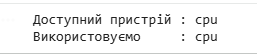

--- Знімок екрана 2026-09-17 124132.png ---


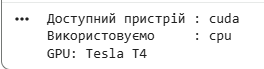

In [254]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/SAI/lab1/screenshots'
valid_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
print(f"Знайдено картинок: {len(image_files)}\n")
for img_name in image_files:
    img_path = os.path.join(folder_path, img_name)
    print(f"--- {img_name} ---")
    display(Image(filename=img_path, width=500))

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [255]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/SAI/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/SAI/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [256]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)



print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [257]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)
#arange_arr = None
#linspace_arr = None

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [258]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))


print(identity.ndim)
print(random_ints.ndim)


2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [259]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std

mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores-mean)/std

print("Середнє:", mean,"Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1 Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [260]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3,4)
row_sums = matrix.sum(axis = 1)
col_sums = matrix.sum(axis = 0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [261]:
df = pd.DataFrame({
    "Name": [
            "Braund, Mr. Owen Harris",
            "Allen, Mr. William Henry",
            "Bonnell, Miss Elizabeth",
        ],
    "score":[
        100,60,81
    ],
})

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням


top = df[df["score"] > 80].sort_values(by="score", ascending=False)
print(top)


                      Name  score
0  Braund, Mr. Owen Harris    100
2  Bonnell, Miss Elizabeth     81


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [262]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"

conditions = [
    df["score"] >= 90,
    df["score"] >=75,
]
choices = ["A","B"]
df['grade'] = np.select(conditions,choices,default = "C")
print(df)


                       Name  score grade
0   Braund, Mr. Owen Harris    100     A
1  Allen, Mr. William Henry     60     C
2   Bonnell, Miss Elizabeth     81     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [263]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)


print(zeros_t.shape)
print(sevens_t.shape)
print(zeros_t.dtype)
print(zeros_t.dtype)


torch.Size([2, 3])
torch.Size([2, 3])
torch.float32
torch.float32


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [264]:
arange_t = torch.arange(0,20,2)
linspace_t = torch.linspace(0,1,5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [265]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3,3)

print(from_list.shape, from_list.dtype,from_list.ndim)
print(random_t.shape, random_t.dtype, random_t.ndim)


torch.Size([2, 2]) torch.int64 2
torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [266]:
n = 5.0
x = torch.tensor(n,requires_grad=True)
y = x **2
y.backward()
print(x.grad.item())
print(x.grad.item() == 2* n)
# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
# надрукувати x.grad.item() і порівняти з 2 * n


10.0
True


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [267]:
x = torch.tensor(0.0, requires_grad=True)
for i in range(20):
  loss = (x-3) **2 +5
  loss.backward()
  lr = 0.1
  with torch.no_grad(): x -= lr* x.grad
  x.grad.zero_()
print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

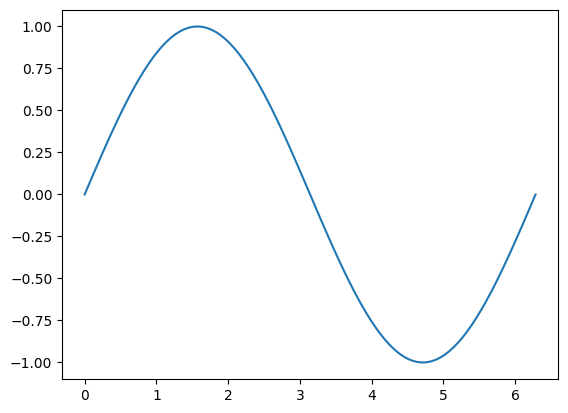

In [268]:
xs= np.linspace(0, 2*np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

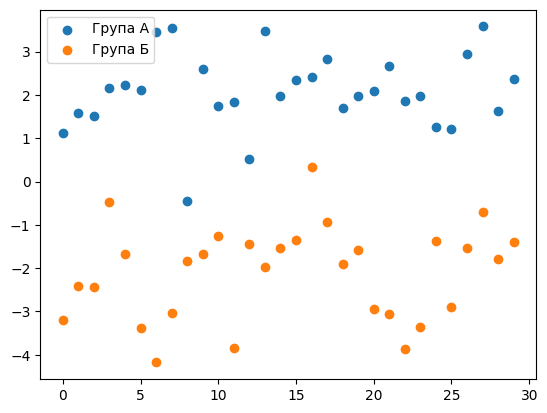

In [269]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2
x = range(30)
plt.scatter(x, group_a, color="C0", label="Група А")
plt.scatter(x, group_b, color="C1", label="Група Б")
plt.legend()
plt.show()
# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [270]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

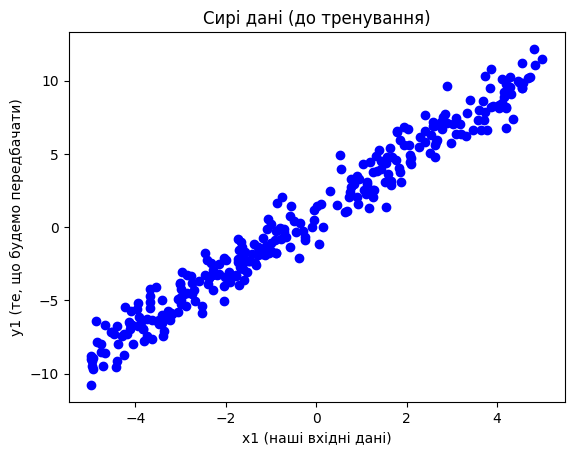

In [271]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"
plt.scatter(x1.numpy(), y1.numpy(), color = "blue")
plt.xlabel("x1 (наші вхідні дані)")
plt.ylabel("y1 (те, що будемо передбачати)")
plt.title("Сирі дані (до тренування)")
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [272]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
indices = torch.randperm(TASK1_N)
train_size = int(0.7 * TASK1_N)
val_size = int(0.15 * TASK1_N)
x1_shuffled = x1[indices]
y1_shuffled = y1[indices]
x_train1 = x1_shuffled[:train_size]
y_train1 = y1_shuffled[:train_size]

x_val1 = x1_shuffled[train_size : train_size + val_size]
y_val1 = y1_shuffled[train_size:train_size+val_size]
x_test1 = x1_shuffled[train_size + val_size:]
y_test1 = y1_shuffled[train_size+val_size:]
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")
print(f"train/val/test: {len(y_train1)}/{len(y_val1)}/{len(y_test1)}")


train/val/test: 210/45/45
train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [273]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


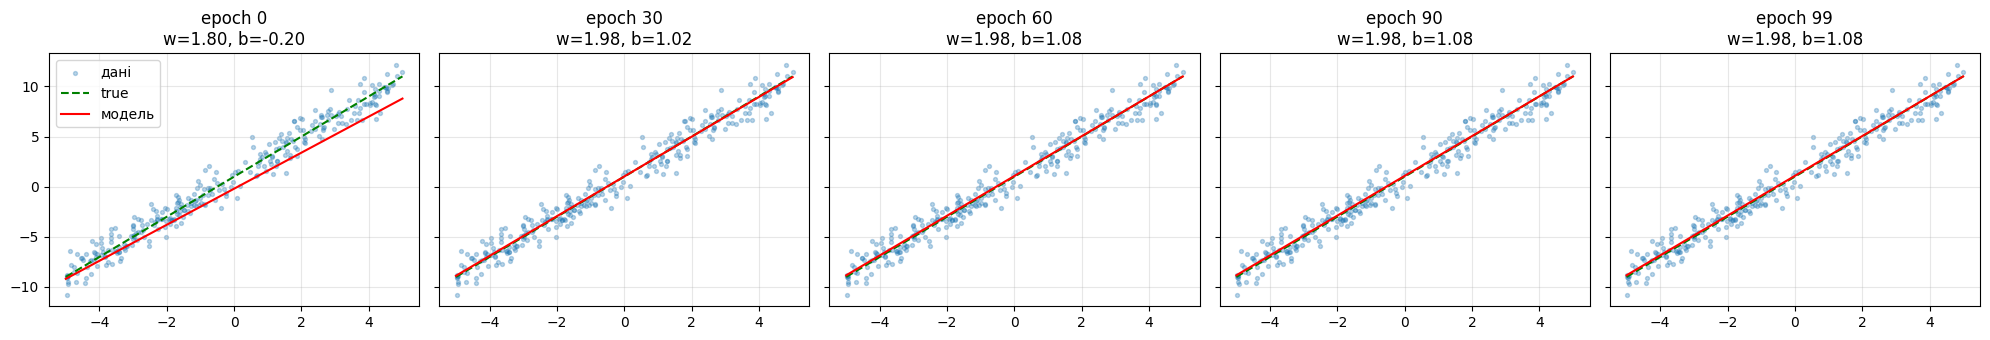

In [274]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

### Сценарій: Залежність кількості відкритих вкладок від часу пошуку багу

У цій вправі я моделюю ситуацію з життя розробника: як довготривалий пошук помилки в коді впливає на захаращеність браузера.

*   **Вхідна змінна ($x$):** Час пошуку помилки в годинах (від 0 до 8 годин).
*   **Цільова змінна ($y$):** Кількість відкритих вкладок у браузері.
*   **Зсув ($b = 5.0$):** Навіть коли ми тільки сідаємо за роботу (час = 0), у нас вже відкрито близько 5 базових вкладок (пошта, музика, ChatGPT, месенджер, GitHub).
*   **Вага ($w = 12.0$):** Кожна година безуспішного дебагу змушує нас гуглити нові помилки. В середньому за годину ми відкриваємо 12 нових сторінок на StackOverflow та в документації.
*   **Шум (noise):** Випадкові відхилення. Іноді ми психуємо і закриваємо половину вкладок, а іноді відкриваємо 10 вкладок з котиками, щоб заспокоїти нерви. Тому додаємо нормальний шум.

# Генерація та збереження в csv
Тут створюємо дані за сценарієм та зберігаємо їх у файл

In [275]:
TRUE_W = 12.0
TRUE_B = 5.0
N_SAMPLES = 250

x_hours = torch.empty(N_SAMPLES,1).uniform_(0,8)
noise = 3.0* torch.randn(N_SAMPLES,1)
y_tabs = TRUE_W * x_hours + TRUE_B + noise

y_tabs = torch.round(y_tabs)
y_tabs[y_tabs < 0] = 0
df = pd.DataFrame({
    'hours_debugging': x_hours.squeeze().numpy(),
    'open_tabs': y_tabs.squeeze().numpy()
})
drive_folder = '/content/drive/MyDrive/SAI/lab1'

os.makedirs(drive_folder, exist_ok=True)

csv_filename = os.path.join(drive_folder, 'dataset.csv')

df.to_csv(csv_filename, index=False)

print(f"Дані успішно згенеровано і надійно збережено на Диск у файл:\n{csv_filename}")

Дані успішно згенеровано і надійно збережено на Диск у файл:
/content/drive/MyDrive/SAI/lab1/dataset.csv


# Функції до завдання

In [276]:
def load_and_split_data(csv_path, test_ratio=0.15, val_ratio=0.15):
    data = pd.read_csv(csv_path)

    x_tensor = torch.tensor(data['hours_debugging'].values, dtype=torch.float32).unsqueeze(1)
    y_tensor = torch.tensor(data['open_tabs'].values, dtype=torch.float32).unsqueeze(1)

    torch.manual_seed(42)
    total_samples = len(x_tensor)
    indices = torch.randperm(total_samples)

    x_shuffled = x_tensor[indices]
    y_shuffled = y_tensor[indices]

    val_size = int(val_ratio * total_samples)
    test_size = int(test_ratio * total_samples)
    train_size = total_samples - val_size - test_size

    x_train = x_shuffled[:train_size]
    y_train = y_shuffled[:train_size]

    x_val = x_shuffled[train_size : train_size + val_size]
    y_val = y_shuffled[train_size : train_size + val_size]

    x_test = x_shuffled[train_size + val_size:]
    y_test = y_shuffled[train_size + val_size:]

    return x_train, y_train, x_val, y_val, x_test, y_test

def train_model(x_train, y_train, epochs=200, lr=0.01, snapshot_step=50):
    model = torch.nn.Linear(in_features=1, out_features=1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    snapshots = []
    x_line = torch.linspace(0, 8, 100).unsqueeze(1)

    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(x_train)
        loss = loss_fn(predictions, y_train)
        loss.backward()
        optimizer.step()

        if epoch == 0 or (epoch + 1) % snapshot_step == 0 or epoch == epochs - 1:
            with torch.no_grad():
                y_line_pred = model(x_line)
                snapshots.append({
                    'epoch': epoch + 1,
                    'w': model.weight.item(),
                    'b': model.bias.item(),
                    'y_line': y_line_pred,
                    'loss': loss.item()
                })

    print(f"Тренування завершено! Фінальний Loss: {loss.item():.4f}")
    return model, snapshots


def plot_training_progress(snapshots, x_train, y_train):
    n_plots = len(snapshots)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
    x_line = torch.linspace(0, 8, 100).numpy()

    for ax, snap in zip(axes, snapshots):
        ax.scatter(x_train.numpy(), y_train.numpy(), color="blue", alpha=0.2, s=15)
        ax.plot(x_line, snap['y_line'].numpy(), color="red", linewidth=2)

        ax.set_title(f"Епоха {snap['epoch']}\nLoss: {snap['loss']:.1f}\nw={snap['w']:.1f}, b={snap['b']:.1f}")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_results(model, x_train, y_train, x_val, y_val, x_test, y_test):
    with torch.no_grad():
        x_line = torch.linspace(0, 8, 100).unsqueeze(1)
        y_line = model(x_line)

    plt.figure(figsize=(9, 6))

    plt.scatter(x_train.numpy(), y_train.numpy(), color="blue", alpha=0.3, label="Train (Тренування)")
    plt.scatter(x_val.numpy(), y_val.numpy(), color="green", alpha=0.6, label="Val (Валідація)")
    plt.scatter(x_test.numpy(), y_test.numpy(), color="orange", alpha=0.9, label="Test (Тест)")

    plt.plot(x_line.numpy(), y_line.numpy(), color="red", linewidth=3, label="Модель")

    plt.xlabel("Години дебагінгу")
    plt.ylabel("Кількість відкритих вкладок")
    plt.title("Як дебаг забиває браузер")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


#Запуск

Тренування завершено! Фінальний Loss: 10.2260

--- Еволюція моделі в процесі навчання ---


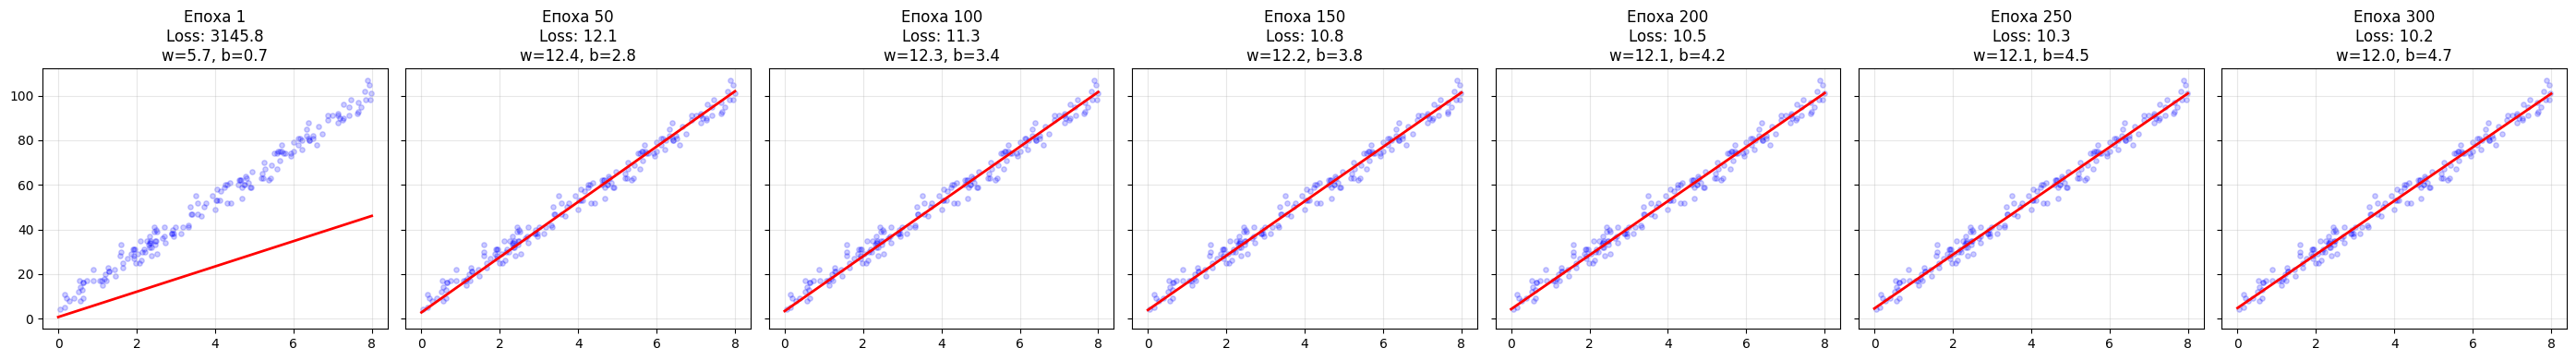


Помилка на Val: 12.7192
Помилка на Test: 7.2149

--- Підсумковий графік з усіма вибірками ---


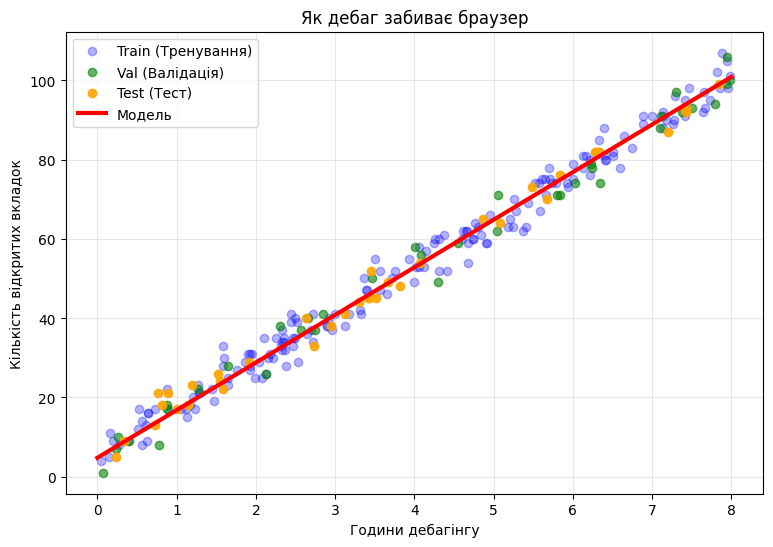

In [277]:
path = '/content/drive/MyDrive/SAI/lab1/dataset.csv'
x_train, y_train, x_val, y_val, x_test, y_test = load_and_split_data(path)

my_model, history_snapshots = train_model(x_train, y_train, epochs=300, lr=0.01, snapshot_step=50)

print("\n--- Еволюція моделі в процесі навчання ---")
plot_training_progress(history_snapshots, x_train, y_train)

with torch.no_grad():
    val_loss = torch.nn.MSELoss()(my_model(x_val), y_val)
    test_loss = torch.nn.MSELoss()(my_model(x_test), y_test)
    print(f"\nПомилка на Val: {val_loss.item():.4f}")
    print(f"Помилка на Test: {test_loss.item():.4f}")

print("\n--- Підсумковий графік з усіма вибірками ---")
plot_results(my_model, x_train, y_train, x_val, y_val, x_test, y_test)

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [278]:
save_path = '/content/drive/MyDrive/SAI/lab1/model.pt'
torch.save(my_model.state_dict(), save_path)
print(f"Модель збережено за шляхом: {save_path}")

Модель збережено за шляхом: /content/drive/MyDrive/SAI/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [ ]:
!pip install -q gradio
loaded_model = torch.nn.Linear(in_features=1, out_features=1)
loaded_model.load_state_dict(torch.load('/content/drive/MyDrive/SAI/lab1/model.pt'))
loaded_model.eval()

def predict_tabs(hours):
  x_tensor = torch.tensor([[float(hours)]], dtype=torch.float32)
  with torch.no_grad():
    prediction = loaded_model(x_tensor).item()
  predicted_tabs = int(round(prediction))
  predicted_tabs = max(0, predicted_tabs)

  return f"Обережно! У тебе буде відкрито приблизно {predicted_tabs} вкладок"

interface = gr.Interface(
    fn=predict_tabs,
    inputs=gr.Slider(minimum=0.0, maximum=12.0, step=0.5, label="Час дебагінгу (в годинах)"),
    outputs=gr.Textbox(label="Результат моделі"),
    title="ШІ-Калькулятор вигорання браузера",
    description="Повзунком вкажи, скільки годин ти шукаєш помилку в коді, і лінійна регресія передбачить, скільки вкладок у браузері ти відкриєш!"
)


interface.launch(share=True)

---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```